In [111]:
import pandas as pd
import random

positive_phrases = [
    "I love this product, it is amazing!",
    "Absolutely fantastic service and friendly staff.",
    "Great quality and fast delivery.",
    "This experience was wonderful, highly recommend.",
    "The app is very user-friendly and smooth.",
    "Excellent customer support, solved my issue quickly.",
    "I am very satisfied with my purchase.",
    "The movie was entertaining and fun.",
    "Best decision I made this year.",
    "The food was delicious and fresh.",
    "Superb quality, exceeded my expectations.",
    "Fast shipping, very reliable.",
    "I enjoyed every moment of this.",
    "Highly professional and courteous staff.",
    "The design is sleek and modern."
]

negative_phrases = [
    "This is the worst experience ever.",
    "I hate waiting so long, terrible!",
    "Not worth the money, very disappointed.",
    "The app keeps crashing, very frustrating.",
    "Customer support was rude and unhelpful.",
    "I regret buying this product.",
    "The movie was boring and too long.",
    "Terrible quality, broke after one use.",
    "The food was cold and tasteless.",
    "Shipping took forever, very unhappy.",
    "Awful service, will not return.",
    "Cheap material, feels flimsy.",
    "I wasted my time and money.",
    "Unprofessional and careless staff.",
    "The design looks outdated and ugly."
]

# Generate synthetic dataset
data = []
for i in range(200):  # 200 rows
    if random.random() > 0.5:
        text = random.choice(positive_phrases)
        label = 1
    else:
        text = random.choice(negative_phrases)
        label = 0
    data.append({"text": text, "label": label})

df = pd.DataFrame(data)

# Save to CSV
df.to_csv("social_media_data.csv", index=False)

print("Synthetic dataset created with", len(df), "rows.")
print(df.head())


Synthetic dataset created with 200 rows.
                                                text  label
0                 The movie was boring and too long.      0
1          The app keeps crashing, very frustrating.      0
2                    Awful service, will not return.      0
3                    I enjoyed every moment of this.      1
4  Excellent customer support, solved my issue qu...      1


### Model Performance Line Chart

This line chart visualizes the performance metrics (Accuracy, Precision, Recall, F1-score) for the different models (Logistic Regression, Random Forest, XGBoost). Since all models achieved perfect scores on the synthetic dataset, the lines overlap at the top.

In [112]:
import plotly.express as px

# Assuming 'metrics_df' is available from previous execution
# If not, you might need to re-run the sentiment_pipeline.py cell (rN_8Fh4oe0w_) to generate it.

if 'metrics_df' in locals():
    fig_line = px.line(metrics_df, title="Model Performance Comparison (Line Chart)")
    fig_line.show()
else:
    print("Metrics DataFrame (metrics_df) not found. Please ensure the model training cell (rN_8Fh4oe0w_) has been executed.")

### Sentiment Distribution Histogram

This histogram shows the distribution of positive (1) and negative (0) sentiment labels in your dataset. It helps to understand if the dataset is balanced or imbalanced.

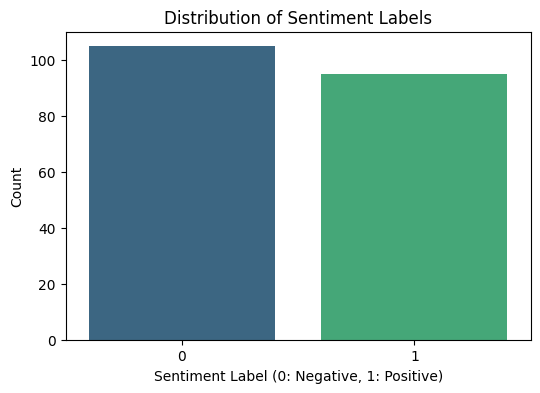

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is available from previous execution (social_media_data.csv loaded)
# If not, you might need to re-run the dataset generation cell (QY57HDSogg4z) or data loading cells.

if 'df' in locals() and 'label' in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x='label', data=df, hue='label', palette='viridis', legend=False)
    plt.title('Distribution of Sentiment Labels')
    plt.xlabel('Sentiment Label (0: Negative, 1: Positive)')
    plt.ylabel('Count')
    plt.show()
else:
    print("DataFrame (df) or 'label' column not found. Please ensure the dataset generation cell (QY57HDSogg4z) has been executed.")

In [114]:
import plotly.express as px

# Line chart of metrics
fig_line = px.line(metrics_df, title="Model Performance Comparison (Line Chart)")
fig_line.show()

Dataset loaded: (200, 2)

--- Training Traditional ML Models ---

--- Training LSTM Model ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning:

Argument `input_length` is deprecated. Just remove it.



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

 Non-trainable params: 0 (0.00 B)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 495ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



Models, vectorizer, and tokenizer saved successfully.

Model Performance:
                      Accuracy  Precision  Recall   F1
Logistic Regression      1.00        1.0     1.0  1.0
Random Forest            1.00        1.0     1.0  1.0
XGBoost                  1.00        1.0     1.0  1.0
LSTM                     0.55        0.0     0.0  0.0



Best Model: Logistic Regression


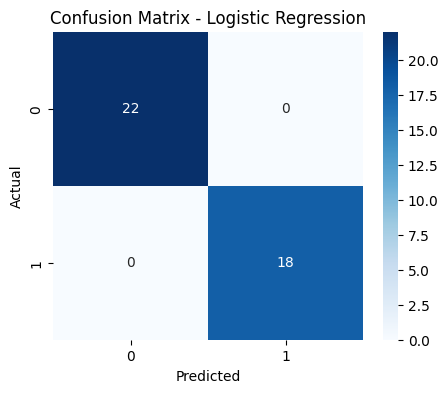


Example prediction (Logistic Regression): Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Example prediction (LSTM): Negative


In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from joblib import dump

# Deep Learning Imports
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# -------------------------------
# 1. Load dataset
# -------------------------------
df = pd.read_csv("social_media_data.csv")
print("Dataset loaded:", df.shape)

# -------------------------------
# 2. Preprocessing
# -------------------------------
df['clean_text'] = df['text'].str.lower()

# Preprocessing for Traditional ML Models (TF-IDF)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_tfidf = vectorizer.fit_transform(df['clean_text'])
y = df['label']

X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Preprocessing for LSTM Model
tokenizer = Tokenizer(num_words=5000, oov_token="<unk>")
tokenizer.fit_on_texts(df['clean_text'])
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1
max_len = 50

sequences = tokenizer.texts_to_sequences(df['clean_text'])
X_padded = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X_padded, y, test_size=0.2, random_state=42)

# -------------------------------
# 3. Train models
# -------------------------------
# Traditional ML Models
models_ml = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

results = {}
roc_data = []
trained_models = {} # To store all trained models for prediction later

print("\n--- Training Traditional ML Models ---")
for name, model in models_ml.items():
    model.fit(X_train_tfidf, y_train_tfidf)
    y_pred = model.predict(X_test_tfidf)
    y_prob = model.predict_proba(X_test_tfidf)[:,1]

    results[name] = {
        "Accuracy": accuracy_score(y_test_tfidf, y_pred),
        "Precision": precision_score(y_test_tfidf, y_pred),
        "Recall": recall_score(y_test_tfidf, y_pred),
        "F1": f1_score(y_test_tfidf, y_pred)
    }
    trained_models[name] = model # Store trained model

    fpr, tpr, _ = roc_curve(y_test_tfidf, y_prob)
    roc_auc = auc(fpr, tpr)
    roc_data.append((name, fpr, tpr, roc_auc))

    dump(model, f"{name.replace(' ', '_').lower()}_model.joblib")

# LSTM Model
print("\n--- Training LSTM Model ---")
embedding_dim = 128

lstm_model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_len),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = lstm_model.fit(X_train_lstm, y_train_lstm,
                          epochs=10,
                          batch_size=32,
                          validation_split=0.1,
                          callbacks=[early_stopping],
                          verbose=0) # Set verbose to 0 to suppress epoch output

y_pred_lstm_prob = lstm_model.predict(X_test_lstm).flatten()
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int)

results["LSTM"] = {
    "Accuracy": accuracy_score(y_test_lstm, y_pred_lstm),
    "Precision": precision_score(y_test_lstm, y_pred_lstm),
    "Recall": recall_score(y_test_lstm, y_pred_lstm),
    "F1": f1_score(y_test_lstm, y_pred_lstm)
}
trained_models["LSTM"] = lstm_model # Store trained model

fpr_lstm, tpr_lstm, _ = roc_curve(y_test_lstm, y_pred_lstm_prob)
roc_auc_lstm = auc(fpr_lstm, tpr_lstm)
roc_data.append(("LSTM", fpr_lstm, tpr_lstm, roc_auc_lstm))

lstm_model.save("lstm_model.h5")

# Save vectorizer and tokenizer
dump(vectorizer, "tfidf_vectorizer.joblib")
dump(tokenizer, "tokenizer.joblib")
print("Models, vectorizer, and tokenizer saved successfully.")

# -------------------------------
# 4. Results summary
# -------------------------------
metrics_df = pd.DataFrame(results).T
print("\nModel Performance:\n", metrics_df)

# -------------------------------
# 5. Visualizations
# -------------------------------
# Bar chart of metrics
fig = px.bar(metrics_df, barmode="group", title="Model Performance Comparison")
fig.show()

# ROC curves
fig = go.Figure()
for name, fpr, tpr, roc_auc in roc_data:
    fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f"{name} (AUC={roc_auc:.2f})"))
fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', line=dict(dash='dash'), name="Random"))
fig.update_layout(title="ROC Curves", xaxis_title="False Positive Rate", yaxis_title="True Positive Rate")
fig.show()

# Confusion matrix for best model
best_model_name = max(results, key=lambda k: results[k]["F1"])
print("\nBest Model:", best_model_name)
best_model_trained = trained_models[best_model_name] # Get the actual trained model

# Determine which test set to use based on the best model type
if best_model_name in models_ml:
    y_test_for_cm = y_test_tfidf
    X_test_for_cm = X_test_tfidf
    y_pred_best = best_model_trained.predict(X_test_for_cm)
elif best_model_name == "LSTM":
    y_test_for_cm = y_test_lstm
    X_test_for_cm = X_test_lstm
    y_pred_best_prob = best_model_trained.predict(X_test_for_cm).flatten()
    y_pred_best = (y_pred_best_prob > 0.5).astype(int)
else:
    y_test_for_cm = y_test_tfidf # Default to TFIDF if no specific test set found
    X_test_for_cm = X_test_tfidf
    y_pred_best = best_model_trained.predict(X_test_for_cm)


cm = confusion_matrix(y_test_for_cm, y_pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -------------------------------
# 6. Live prediction function
# -------------------------------
def predict_sentiment(text, selected_model_name, vec=vectorizer, tok=tokenizer, max_len=max_len, all_trained_models=trained_models):
    clean_text = text.lower()
    model = all_trained_models[selected_model_name]

    if selected_model_name in models_ml:
        X_input = vec.transform([clean_text])
        pred = model.predict(X_input)[0]
    elif selected_model_name == "LSTM":
        sequence = tok.texts_to_sequences([clean_text])
        padded_sequence = pad_sequences(sequence, maxlen=max_len, padding='post', truncating='post')
        pred_prob = model.predict(padded_sequence)[0][0]
        pred = (pred_prob > 0.5).astype(int)
    else:
        X_input = vec.transform([clean_text]) # Default to TFIDF for unknown model types
        pred = model.predict(X_input)[0]

    return "Positive" if pred == 1 else "Negative"

# Example prediction using Logistic Regression
print("\nExample prediction (Logistic Regression):", predict_sentiment("I really enjoyed this service!", "Logistic Regression"))
print("Example prediction (LSTM):", predict_sentiment("This is absolutely terrible!", "LSTM"))

In [105]:
# streamlit_app.py
import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score
from joblib import load

# Load pre-trained models (trained offline and saved with joblib)
log_reg_model = load("log_reg_model.joblib")
rf_model = load("rf_model.joblib")
xgb_model = load("xgb_model.joblib")
vectorizer = load("tfidf_vectorizer.joblib")

st.title("Sentiment Analysis Dashboard")

uploaded_file = st.file_uploader("Upload CSV with 'text' and 'label' columns")
if uploaded_file:
    df = pd.read_csv(uploaded_file)
    st.write("Dataset Preview:", df.head())

    X = vectorizer.transform(df['text'])
    y_true = df['label']

    models = {
        "Logistic Regression": log_reg_model,
        "Random Forest": rf_model,
        "XGBoost": xgb_model
    }

    results = {}
    roc_data = []

    for name, model in models.items():
        y_pred = model.predict(X)
        y_prob = model.predict_proba(X)[:,1]

        results[name] = {
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred),
            "Recall": recall_score(y_true, y_pred),
            "F1": f1_score(y_true, y_pred)
        }

        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        roc_data.append((name, fpr, tpr, roc_auc))

    # Metrics Comparison
    metrics_df = pd.DataFrame(results).T
    st.subheader("Model Performance Comparison")
    fig = px.bar(metrics_df, barmode="group", title="Model Performance Comparison")
    st.plotly_chart(fig)

    # ROC Curves
    st.subheader("ROC Curves")
    fig = go.Figure()
    for name, fpr, tpr, roc_auc in roc_data:
        fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f"{name} (AUC={roc_auc:.2f})"))
    fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', line=dict(dash='dash'), name="Random"))
    st.plotly_chart(fig)

    # Confusion Matrix for best model
    best_model_name = max(results, key=lambda k: results[k]["F1"])
    st.write(f"Best Model: {best_model_name}")
    best_model = models[best_model_name]
    y_pred_best = best_model.predict(X)
    cm = confusion_matrix(y_true, y_pred_best)

    fig, ax = plt.subplots()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    st.pyplot(fig)

# Live Prediction
st.subheader("Live Sentiment Prediction")
user_input = st.text_area("Enter text:")
if st.button("Predict"):
    clean_input = user_input.lower()
    X_input = vectorizer.transform([clean_input])
    pred = log_reg_model.predict(X_input)[0]
    st.write("Predicted Sentiment:", "Positive" if pred==1 else "Negative")


2026-03-27 18:50:37.219 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-27 18:50:37.220 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-27 18:50:37.221 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-27 18:50:37.221 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-27 18:50:37.222 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-27 18:50:37.222 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-27 18:50:37.223 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-27 18:50:37.224 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

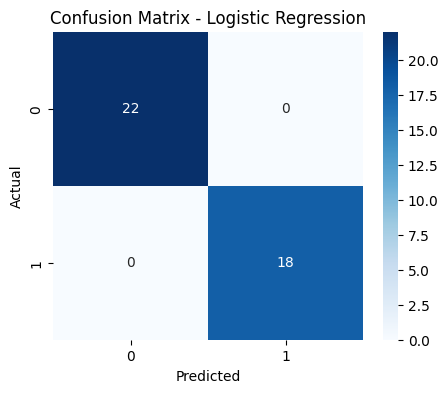

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Assuming metrics_df, roc_data, cm, best_model_name are available from previous execution

# Bar chart of metrics
fig_bar = px.bar(metrics_df, barmode="group", title="Model Performance Comparison")
fig_bar.show()

# ROC curves
fig_roc = go.Figure()
for name, fpr, tpr, roc_auc in roc_data:
    fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f"{name} (AUC={roc_auc:.2f})"))
fig_roc.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', line=dict(dash='dash'), name="Random"))
fig_roc.update_layout(title="ROC Curves", xaxis_title="False Positive Rate", yaxis_title="True Positive Rate")
fig_roc.show()

# Confusion matrix for best model
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Sentiment Distribution Histogram

In [107]:
!pip install nltk tensorflow transformers
import nltk
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

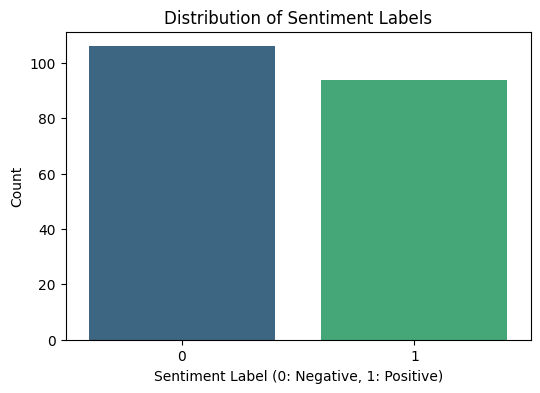

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, hue='label', palette='viridis', legend=False)
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment Label (0: Negative, 1: Positive)')
plt.ylabel('Count')
plt.show()

In [109]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from joblib import dump

# Example dataset (replace with your own CSV)
df = pd.read_csv("social_media_data.csv")  # must have 'text' and 'label'

# Basic preprocessing
df['clean_text'] = df['text'].str.lower()

# TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = vectorizer.fit_transform(df['clean_text'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train models
log_reg_model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
rf_model = RandomForestClassifier(n_estimators=100).fit(X_train, y_train)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss').fit(X_train, y_train)

# Save models and vectorizer
dump(log_reg_model, "log_reg_model.joblib")
dump(rf_model, "rf_model.joblib")
dump(xgb_model, "xgb_model.joblib")
dump(vectorizer, "tfidf_vectorizer.joblib")

print("Models and vectorizer saved successfully.")


Models and vectorizer saved successfully.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[18:50:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




In [110]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from joblib import dump

# Load your dataset
df = pd.read_csv("social_media_data.csv")  # must have 'text' and 'label'

# Preprocessing (basic lowercase)
df['clean_text'] = df['text'].str.lower()

# TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = vectorizer.fit_transform(df['clean_text'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train models
log_reg_model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
rf_model = RandomForestClassifier(n_estimators=100).fit(X_train, y_train)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss').fit(X_train, y_train)

# Save models and vectorizer
dump(log_reg_model, "log_reg_model.joblib")
dump(rf_model, "rf_model.joblib")
dump(xgb_model, "xgb_model.joblib")
dump(vectorizer, "tfidf_vectorizer.joblib")


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[18:50:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




['tfidf_vectorizer.joblib']